# 1. Import and Hardware setup

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

import matplotlib.pyplot as plt

!pip install tqdm ipywidgets -q
from tqdm.auto import tqdm

import math

In [25]:
DATA_PATH = './Data'
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(device)

cuda


# 2. Hyperparameter

In [26]:
IN_CHANNELS = 3
BATCH_SIZE = 128
NUM_CLASSES = 101
IMG_SIZE = 224

LR = 1e-3
EPOCHS = 1
SEED = 42

MODEL_NAME = "ConvNeXtV1-T"

# 3. Data Preparation

In [27]:
stats = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomRotation(15),
    transforms.RandomCrop(IMG_SIZE),
    transforms.TrivialAugmentWide(),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

In [28]:
import os
import random
import numpy as np

def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [29]:
# Download training data as dummy without transforms
dummy_data = datasets.Food101(root=DATA_PATH, split="train", download=True)

# Split the dummy data into two tmp subset
train_size = int(0.8 * len(dummy_data))
val_size = len(dummy_data) - train_size
split_generator = torch.Generator().manual_seed(SEED)

train_tmp_subset, val_tmp_subset = random_split(
    dummy_data, [train_size, val_size], generator=split_generator
)

train_indices = train_tmp_subset.indices
val_indices = val_tmp_subset.indices

# Create the subsets with correct transforms
train_dataset = datasets.Food101(
    root=DATA_PATH, split="train", download=False, transform=train_transform
)
val_dataset = datasets.Food101(
    root=DATA_PATH, split="train", download=False, transform=test_transform
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

# Download test dataset
test_dataset = datasets.Food101(
    root=DATA_PATH, split="test", download=True, transform=test_transform
)

In [30]:
train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_subset, 
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    worker_init_fn=seed_worker,
    generator=train_generator,
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


# 4. Model Architecture

In [ ]:
class DropPath(nn.Module):
    def __init__(self, drop_path_prob: float = 0.0):
        super().__init__()
        self.survival_prob = 1 - drop_path_prob

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if not self.training or self.survival_prob == 1.0:
            return x

        # Create an empty tensor on the same device as samples
        batch_size = x.shape[0]
        noise = torch.empty(batch_size, 1, 1, 1, device=x.device)

        # Fill the noise tensor random with 1 and 0 using bernoulli
        noise.bernoulli_(self.survival_prob)

        # Inverted Scaling: scale the signal up to keep the same amount
        # of signal the same as eval, otherwise the prediction will be
        # ruined if the eval signal way bigger than train signal
        if self.survival_prob > 0:
            noise.div_(self.survival_prob)

        return x * noise


class ConvNeXtBlock(nn.Module):
    def __init__(self, inplanes, expand_ratio=4, drop_path_prob=0.0, layer_scale_init_value=1e-6):
        super().__init__()
        planes = inplanes * expand_ratio
        self.drop_path = (
            DropPath(drop_path_prob) if drop_path_prob > 0 else nn.Identity()
        )

        self.dw_conv = nn.Conv2d(
            in_channels=inplanes,
            out_channels=inplanes,
            kernel_size=7,
            stride=1,
            padding=3,
            groups=inplanes,
        )

        self.pw_conv1 = nn.Conv2d(
            in_channels=inplanes, out_channels=planes, kernel_size=1
        )

        self.pw_conv2 = nn.Conv2d(
            in_channels=planes,
            out_channels=inplanes,
            kernel_size=1,
        )

        self.norm = nn.LayerNorm(inplanes, eps=1e-6)
        self.gelu = nn.GELU()
        
        # Layer Scale (learnable gamma)
        self.gamma = (
            nn.Parameter(layer_scale_init_value * torch.ones(inplanes))
            if layer_scale_init_value > 0
            else None
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        shortcut = x
        x = self.dw_conv(x)
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = x.permute(0, 3, 1, 2)
        x = self.pw_conv1(x)
        x = self.gelu(x)
        x = self.pw_conv2(x)
        
        if self.gamma is not None:
            x = x * self.gamma.view(1, -1, 1, 1)
        
        x = self.drop_path(x)

        return shortcut + x


class Downsampling(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=2,
            stride=2,
        )
        self.layer_norm = nn.LayerNorm(in_channels, eps=1e-6)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.permute(0, 2, 3, 1)
        x = self.layer_norm(x)
        x = x.permute(0, 3, 1, 2)
        return self.conv(x)


class Stem(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=4,
            stride=4,
        )
        self.layer_norm = nn.LayerNorm(out_channels, eps=1e-6)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = x.permute(0, 2, 3, 1)
        x = self.layer_norm(x)
        x = x.permute(0, 3, 1, 2)
        return x


class ConvNeXtV1(nn.Module):
    def __init__(self, model_name, in_channels, num_classes):
        super().__init__()
        model_configs = {
            "ConvNeXtV1-T": {
                "first_out": 96,
                "inplanes": (96, 192, 384, 768),
                "B": (3, 3, 9, 3),
                "drop_path_rate": 0.1,
            },
            "ConvNeXtV1-S": {
                "first_out": 96,
                "inplanes": (96, 192, 384, 768),
                "B": (3, 3, 27, 3),
                "drop_path_rate": 0.4,
            },
            "ConvNeXtV1-B": {
                "first_out": 128,
                "inplanes": (128, 256, 512, 1024),
                "B": (3, 3, 27, 3),
                "drop_path_rate": 0.5,
            },
            "ConvNeXtV1-L": {
                "first_out": 192,
                "inplanes": (192, 384, 768, 1536),
                "B": (3, 3, 27, 3),
                "drop_path_rate": 0.5,
            },
            "ConvNeXtV1-XL": {
                "first_out": 256,
                "inplanes": (256, 512, 1024, 2048),
                "B": (3, 3, 27, 3),
                "drop_path_rate": 0.2,
            },
        }

        layers = []
        out_channels = model_configs[model_name]["first_out"]
        layers.append(Stem(in_channels, out_channels))

        repeat = model_configs[model_name]["B"]
        inplanes = model_configs[model_name]["inplanes"]
        drop_path_rate = model_configs[model_name]["drop_path_rate"]

        layers.extend(
            [
                self._make_layer(repeat[0], inplanes[0], drop_path_rate),
                Downsampling(inplanes[0], inplanes[1]),
                self._make_layer(repeat[1], inplanes[1], drop_path_rate),
                Downsampling(inplanes[1], inplanes[2]),
                self._make_layer(repeat[2], inplanes[2], drop_path_rate),
                Downsampling(inplanes[2], inplanes[3]),
                self._make_layer(repeat[3], inplanes[3], drop_path_rate),
            ]
        )

        self.block = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(1),
            nn.LayerNorm(inplanes[3], eps=1e-6),
            nn.Linear(inplanes[3], num_classes),
        )

    def _make_layer(self, repeat, inplanes, drop_path_rate):
        layers = []
        for _ in range(repeat):
            layers.append(
                ConvNeXtBlock(
                    inplanes=inplanes,
                    drop_path_prob=drop_path_rate,
                )
            )
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.block(x)
        return self.head(x)

In [32]:
print(f"Using {MODEL_NAME}")
model = ConvNeXtV1(
    model_name=MODEL_NAME,
    in_channels=IN_CHANNELS,
    num_classes=NUM_CLASSES,
).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters())/1e6):.2f}M")

Using ConvNeXtV1-T
Total parameters: 27.89M


# 5. Training Preparation

In [33]:
class EarlyStopping:
    def __init__(
        self, patience=10, delta=0, verbose=False, save_path="best_checkpoint.pth"
    ):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.save_path = save_path
        self.verbose = verbose

        self.early_stop = False
        self.counter = 0
        self.best_loss = None
    
    def __call__(self, model, val_loss):
        # 1. For the first epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        
        # 2. If the loss didnt decrease as expect
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        
        # 3. The loss decreased properly
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print("Saving best checkpoint ...")
        state_dict = (
            model.module.state_dict()
            if hasattr(model, "module")
            else model.state_dict()
        )
        torch.save(state_dict, self.save_path)

In [34]:
def sample_cutmix_box(batch_shape, mix_ration):
    """Generate a random CutMix box for NCHW tensors
    Return: y_min, y_max, x_min, x_max
    """
    img_height = batch_shape[2]
    img_width = batch_shape[3]
    
    cutmix_scale = np.sqrt(1.0 - mix_ration)
    cut_height = int(img_height * cutmix_scale)
    cut_width = int(img_width * cutmix_scale)
    
    # Center
    cx = np.random.randint(0, img_width)
    cy = np.random.randint(0, img_height)
    
    # Calculate the box coordinates
    x_min = np.clip(cx - cut_width // 2, 0, img_width)
    x_max = np.clip(cx + cut_width // 2, 0, img_width)
    y_min = np.clip(cy - cut_height // 2, 0, img_height)
    y_max = np.clip(cy + cut_height // 2, 0, img_height)
    
    return y_min, y_max, x_min, x_max

def apply_mixup_cutmix(x, y, p=0.5, alpha=1.0, cutmix_prob=0.5):
    """Returns:
        - x_mixed: The augmented image data 
        - y_a: The original labels of the current batch
        - y_b: The shuffled labels
        - lam: The mixing coefficient
        - use_mix: True or False
    """
    use_mix = np.random.rand() < p
    
    # 1. Not using mix
    if not use_mix:
        return x, y, y, 1.0, False
    
    # 2. Using mix
    # Create the mixing coefficient
    lam = float(np.random.beta(alpha, alpha))
    
    # Create a shuffled list of indices to decide which images
    # in the batch will be mixed together
    rand_index = torch.randperm(x.size(0), device=x.device)
    y_a, y_b = y, y[rand_index]
    
    # CutMix
    if np.random.rand() < cutmix_prob:
        x = x.clone()
        
        # Get the box coordinates
        y_min, y_max, x_min, x_max = sample_cutmix_box(x.size(), lam)
        
        # Put the other image in the box
        x[:, :, y_min:y_max, x_min:x_max] = x[rand_index, :, y_min:y_max, x_min:x_max]
        
        # Recalculate new lamda coefficient
        lam = 1.0 - ((y_max - y_min) * (x_max - x_min) / (x.size(-2) * x.size(-1)))
    # MixUp
    else:
        x = lam * x + (1.0 - lam) * x[rand_index, :]
    return x, y_a, y_b, lam, True

In [35]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer=optimizer,
    max_lr=LR,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    div_factor=10,
    final_div_factor=100,
)

# Scaler for using AMP - Mixed Precision
scaler = torch.amp.GradScaler(device)

In [36]:
def train(model, loader, criterion, optimizer, scaler, scheduler):
    model.train()
    train_loss, train_acc = 0.0, 0.0
    loop = tqdm(loader, desc="Training", leave=False)

    for x, y in loop:
        # Move samples and labels to device
        x, y = x.to(device), y.to(device)

        # Zero out the gradients of last batch
        optimizer.zero_grad(set_to_none=True)

        # Using CutMix/MixUp
        x, y_a, y_b, lam, use_mix = apply_mixup_cutmix(
            x, y, p=0.5, alpha=1.0, cutmix_prob=0.5
        )

        with torch.amp.autocast(device_type=device.type):
            # Get prediction
            out = model(x)

            # Get the loss
            loss = (
                lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
                if use_mix
                else criterion(out, y)
            )

        # Scale up the loss and backpropagate
        scaler.scale(loss).backward()

        # Unscale and clip the gradients
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update the paramters
        scaler.step(optimizer)

        # Update the scaler
        scaler.update()

        # Update lr after each batch because of using OneCycleLR
        scheduler.step()

        train_loss += loss.detach() * x.size(0)
        if use_mix:
            train_acc += (
                lam * (out.argmax(1) == y_a).float()
                + (1 - lam) * (out.argmax(1) == y_b).float()
            ).sum()
        else:
            train_acc += (out.argmax(1) == y).sum()
    return train_loss.item() / len(loader.dataset), train_acc.item() / len(
        loader.dataset
    )


def validate(model, loader, criterion):
    model.eval()
    val_loss, val_acc = 0.0, 0.0
    loop = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            with torch.amp.autocast(device_type=device.type):
                out = model(x)
                loss = criterion(out, y)
            val_loss += loss.detach() * x.size(0)
            val_acc += (out.argmax(1) == y).sum()
    return val_loss.item() / len(loader.dataset), val_acc.item() / len(loader.dataset)


def test(model, loader):
    model.eval()
    test_acc = 0.0
    loop = tqdm(loader, desc="Testing", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            out = model(x)
            test_acc += (out.argmax(1) == y).sum()
    return test_acc / len(loader.dataset)

# 6. Train

In [37]:
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
early_stopping = EarlyStopping(patience=10, delta=0.01)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scaler, scheduler)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, " +
          f"train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")
    
    early_stopping(model, val_loss)
    if early_stopping.early_stop:
        print("Early Stopping")
        break

best_model = model.module if hasattr(model, 'module') else model
best_model.load_state_dict(torch.load('best_checkpoint.pth', map_location=device))
test_acc = test(model, test_loader)
print(f"Final test accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch 1/1: train_loss: 4.5664, val_loss: 4.3163, train_acc: 0.0261, val_acc: 0.0532


Testing:   0%|          | 0/198 [00:00<?, ?it/s]

Final test accuracy: 0.0583


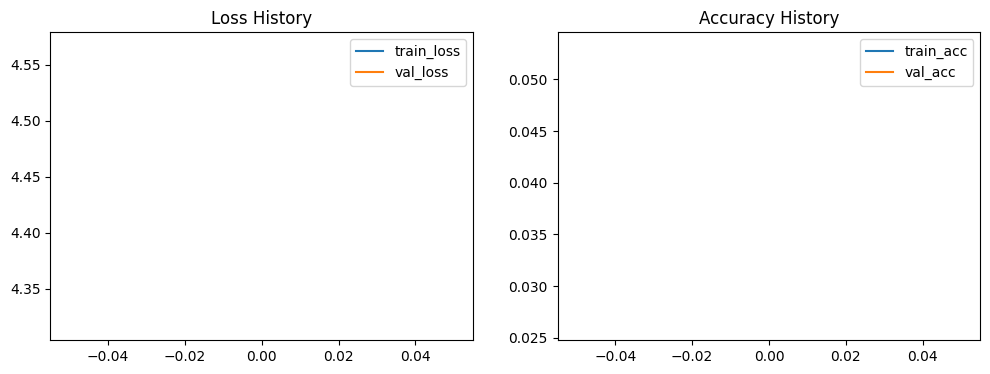

In [38]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train_loss')
plt.plot(val_losses, label='val_loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='train_acc')
plt.plot(val_accuracies, label='val_acc')
plt.title('Accuracy History')
plt.legend()

# 7. GradCAM

In [ ]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_image, target_class=None):
        self.model.eval()

        # 1) Forward
        output = self.model(input_image)

        # 2) Target class
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        # 3) Backward
        self.model.zero_grad()
        score = output[0, target_class]
        score.backward()

        # 4) Weights via GAP on gradients
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)

        # 5) Weighted sum of activations
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        cam = F.relu(cam)

        # 6) Resize to input
        cam = F.interpolate(cam, size=input_image.shape[2:], mode="bilinear", align_corners=False)

        # 7) Normalize
        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam

def plot_gradcam(image_tensor, cam_heatmap):
    img = image_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.clip(std * img + mean, 0, 1)

    jet = plt.get_cmap("jet")
    heatmap_colored = jet(cam_heatmap)[..., :3]
    overlay = np.clip(0.4 * heatmap_colored + 0.6 * img, 0, 1)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img); ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(cam_heatmap, cmap="jet"); ax[1].set_title("GradCAM"); ax[1].axis("off")
    ax[2].imshow(overlay); ax[2].set_title("Overlay"); ax[2].axis("off")
    plt.tight_layout()
    plt.show()

target_layer = model.block[-1][-1]  # ConvNeXtBlock

grad_cam = GradCAM(model, target_layer)

sample_images, _ = next(iter(test_loader))
sample_image = sample_images[0:1].to(device)

heatmap = grad_cam.generate_heatmap(sample_image)
plot_gradcam(sample_image, heatmap)


AttributeError: 'ConvNeXtV1' object has no attribute 'layer4'